# Análisis Inicial

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Configuraciones adicionales

In [2]:
# Configuramos que se muestren todas las columnas de nuestros dataframes
pd.set_option('display.max_columns', None)

## Dataset 1:  **bank-additional**

### Contexto columnas:

- `age`: La edad del cliente.
- `job`: La ocupación o profesión del cliente.
- `marital`: El estado civil del cliente.
- `education`: El nivel educativo del cliente.
- `default`: Indica si el cliente tiene algún historial de incumplimiento de pagos (1: Sí, 0: No).
- `housing`: Indica si el cliente tiene un préstamo hipotecario (1: Sí, 0: No).
- `loan`: Indica si el cliente tiene algún otro tipo de préstamo (1: Sí, 0: No).
- `contact`: El método de contacto utilizado para comunicarse con el cliente.
- `duration`: La duración en segundos de la última interacción con el cliente.
- `campaign`: El número de contactos realizados durante esta campaña para este cliente.
- `pdays`: Número de días que han pasado desde la última vez que se contactó con el cliente durante esta campaña.
- `previous`: Número de veces que se ha contactado con el cliente antes de esta campaña.
- `poutcome`: Resultado de la campaña de marketing anterior.
- `emp.var.rate`: La tasa de variación del empleo.
- `cons.price.idx`: El índice de precios al consumidor.
- `cons.conf.idx`: El índice de confianza del consumidor.
- `euribor3m`: La tasa de interés de referencia a tres meses.
- `nr.employed`: El número de empleados.
- `y`: Indica si el cliente ha suscrito un producto o servicio (Sí/No).
- `date`: La fecha en la que se realizó la interacción con el cliente.
- `contact_month`: Mes en el que se realizó la interacción con el cliente durante la campaña de marketing.
- `contact_year`: Año en el que se realizó la interacción con el cliente durante la campaña de marketing.
- `id_`: Un identificador único para cada registro en el dataset.

### Apretura y primer análisis del DF

In [3]:
df_bank = pd.read_csv('files/input/bank-additional.csv')

In [4]:
#  Mostramos el dataframe
df_bank.sample(3)

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
14672,14769,32.0,blue-collar,SINGLE,basic.6y,0.0,1.0,0.0,cellular,46,1,999,0,NONEXISTENT,1.4,"93,918","-42,7","4,957","5228,1",no,26-noviembre-2016,40.964,-115.084,c7781ed8-9672-46c1-8a5c-fe839c6ac3c2
33511,33655,43.0,admin.,MARRIED,high.school,0.0,1.0,0.0,cellular,200,1,999,0,NONEXISTENT,-1.8,"92,893","-46,2",NaN,"5099,1",no,8-junio-2016,38.552,-117.012,614537ff-7f19-4cd1-a2fd-a6c58fe1570c
37977,38144,70.0,housemaid,DIVORCED,basic.4y,0.0,0.0,0.0,cellular,213,1,999,1,FAILURE,-3.4,"92,379","-29,8","0,75","5017,5",no,21-agosto-2017,43.571,-102.445,4910ee8c-b2ab-4175-90fb-38e61b430a41


In [5]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  object 
 3   marital         42915 non-null  object 
 4   education       41193 non-null  object 
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  object 
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  object 
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  object 
 16  cons.conf.idx   43000 non-null  object 
 17  euribor3m       33744 non-null 

#### **Observaciones** y **Ajustes** preeliminares

- Columna ` Unnamed: 0` innecesaria.
- Nombres de varias columnas con un formato poco optimo (ej. separación con puntos)
- Columnas con tipos incorrectos:
    - `age` -->  es float, debería ser integer
    - `cons.price.idx`, `cons.conf.idx` , ` euribor3m` y ` nr.employed` --> son strings y deberían ser float
        - El error está en que los decimales están separados por **coma** en vez de por **punto**
    - `date` --> String y debería ser fecha
    - `default, `housing` y `loan` --> son floats pero en realidad son variables categoricas (Sí o no), asi decididmos cambiar los numeros por texto y convertirlas a formato string (0:No, 1, Yes)
- En el dataset no apartecen ni `contact_month` ni `contact_year`, pero se puede acceder a esa información a partir de `date`.

##### Ajustes iniciales

###### Eliminar columna Unnamed

In [6]:
# Eliminamos la columna 'Unnamed: 0'
df_bank = df_bank.drop(columns='Unnamed: 0')

# Y revisamos que se ha eliminado correctamente
df_bank.sample(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
35174,30.0,technician,MARRIED,basic.9y,0.0,1.0,0.0,cellular,54,2,999,0,NONEXISTENT,-1.8,"92,893","-46,2","1,25","5099,1",no,19-marzo-2018,24.688,-84.385,dd404ef8-1a6f-42eb-8fdf-8bfefbb98a48
17521,48.0,self-employed,MARRIED,university.degree,NaN,0.0,0.0,cellular,191,2,999,0,NONEXISTENT,1.4,"93,918","-42,7","4,962","5228,1",no,27-febrero-2019,35.100,-116.626,92824c92-3288-429d-84b1-b08e7c468fb1


###### Formatear nombres de las columnas
- Para ello creamos una función que podamos reutiliza en la carpeta **scr** en el archivo **formatting_utils**

In [7]:
# Importamos la funcion
from scr.formatting_utils import column_names_formatting

In [8]:
# Ejecutamos la funcion en el dataframe
df_bank = column_names_formatting(df_bank)

In [9]:
# Comprobamos que los ajustes se han realizado correctamente
df_bank.sample(2)

,AGE,JOB,MARITAL,EDUCATION,DEFAULT,HOUSING,LOAN,CONTACT,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,EMPVARRATE,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED,Y,DATE,LATITUDE,LONGITUDE,ID
15996,30.0,blue-collar,MARRIED,basic.9y,0.0,0.0,0.0,cellular,189,1,999,0,NONEXISTENT,1.4,"93,918","-42,7","4,961","5228,1",no,19-mayo-2015,33.062,-105.558,298fc14d-26ed-4272-83a1-684e89f478a4
10296,51.0,blue-collar,MARRIED,basic.9y,NaN,1.0,0.0,telephone,254,1,999,0,NONEXISTENT,1.4,"94,465","-41,8","4,96","5228,1",no,26-octubre-2018,24.469,-85.346,d7ab5479-9068-432b-881b-dc043bc79d92


###### Ajuste tipo de datos de las columnas

In [10]:
# Cambiamos el tipo de `age` a integer
# df_bank['AGE'] = df_bank['AGE'].astype("'Int64'")

In [11]:
# En las columnas numericas con decimales separados por comas, hacemos el cambio a puntos
to_float_columns = ['CONSPRICEIDX', 'CONSCONFIDX', 'EURIBOR3M', 'NREMPLOYED']

df_bank[to_float_columns] = df_bank[to_float_columns].apply(lambda x: x.str.replace(",","."))

In [12]:
# Comprobamos que el cambio se ha realizado correctamente
df_bank[to_float_columns].sample(2)

,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED
37949,92.379,-29.8,0.749,5017.5
41457,94.465,-41.8,4.959,5228.1


In [13]:
# Cambiamos el tipo de las columnas a float
df_bank[to_float_columns] = df_bank[to_float_columns].astype("float64")

In [14]:
# Ajustamos el tipo de la columna 'DATE' a tipo fecha

# Como los nombres de los meses están en español, primero tenemos que cambiarlos a inglés para poder hacer el ajuste
# Diccionario de meses español → inglés
meses = {
    "enero": "january", "febrero": "february", "marzo": "march", "abril": "april",
    "mayo": "may", "junio": "june", "julio": "july", "agosto": "august",
    "septiembre": "september", "octubre": "october", "noviembre": "november", "diciembre": "december"
}

# Reemplazamos los meses en las columna
for es,en in meses.items():
    df_bank["DATE"] = df_bank["DATE"].replace(es,en,regex=True)


# Cambiamos el el tipo de dato a fecha
df_bank["DATE"] = pd.to_datetime(df_bank["DATE"], format="%d-%B-%Y")

In [15]:
# Comprobamos que el ajuste se ha realizado correctamente
df_bank["DATE"].sample(3)

36209   2015-07-04
33238   2017-11-19
25724   2015-04-30
Name: DATE, dtype: datetime64[ns]

In [16]:
# Ajustamos las columnas `default, `housing` y `loan` 

# Seleccionamos las columnas
bool_cols = ['DEFAULT', 'HOUSING', 'LOAN']

# Construimos el mapa con los valores a intercambiar
yes_no = {0:'No', 1:'Yes'}

# Reemplazamos los valores en las columnas
for col in bool_cols:
    for n,s in yes_no.items():
        df_bank[col] = df_bank[col].replace(n,s,regex=True)

In [17]:
# Y comprobamos que todos los tipos se han ajustado correctamente
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   AGE           37880 non-null  float64       
 1   JOB           42655 non-null  object        
 2   MARITAL       42915 non-null  object        
 3   EDUCATION     41193 non-null  object        
 4   DEFAULT       34019 non-null  object        
 5   HOUSING       41974 non-null  object        
 6   LOAN          41974 non-null  object        
 7   CONTACT       43000 non-null  object        
 8   DURATION      43000 non-null  int64         
 9   CAMPAIGN      43000 non-null  int64         
 10  PDAYS         43000 non-null  int64         
 11  PREVIOUS      43000 non-null  int64         
 12  POUTCOME      43000 non-null  object        
 13  EMPVARRATE    43000 non-null  float64       
 14  CONSPRICEIDX  42529 non-null  float64       
 15  CONSCONFIDX   43000 non-null  float6

#### Duplicados

In [18]:
# Comprobamos si tenemos lineas duplicadas en nuestro dataframe
df_bank.duplicated().sum()

np.int64(0)

No tenemos valores duplicados

#### Valores Nulos

Por el momento únicamente los vamos a identificar, no los vamos a gestionar.

Para facilitarnos la exploración creamos una funcion de análisis en la carpeta **scr**, fichero **explore_utils** llamado `null_analysis`

In [19]:
# importamos la funcion

from scr.explore_utils import null_analysis

In [20]:
nulos = null_analysis(df_bank).sort_values(by= 'NULL_PERCENT',ascending=False)

In [21]:
nulos[nulos['NULL_PERCENT'] > 0]

,COLUMN_NAME,NON_NULL_COUNT,NULL_COUNT,NULL_PERCENT,DTYPE
16,EURIBOR3M,33744,9256,21.53,float64
4,DEFAULT,34019,8981,20.89,object
0,AGE,37880,5120,11.91,float64
3,EDUCATION,41193,1807,4.20,object
5,HOUSING,41974,1026,2.39,object
6,LOAN,41974,1026,2.39,object
14,CONSPRICEIDX,42529,471,1.10,float64
1,JOB,42655,345,0.80,object
19,DATE,42752,248,0.58,datetime64[ns]
2,MARITAL,42915,85,0.20,object


##### Análisis de nulos
- Tenemos tres columnas con las de un 20% de valores nulos, un valor muy alto
    - `EURIBOR3M`
    -  `DEFAULT`
- Una columna con mas de un 10% de valores nulos, también un valor significativo aunque moderado
    - `AGE`
- Y el resto con un porcentaje de nulos que no supera el 5&
    - Destaca `EDUCATION`, el más cercano  ese 5%
    - Entre el 1& y el 3 % se encuentran `HOUSING`, `LOAN` y `CONSPRICEIDX`
    - Y tres no llegan ni al 1% de valores nulos:
        - `JOB`, `DATE` y `MARITAL`

> Para esta parte de análisis inicial por el momento no vamos a realizar una gestion de valores nulos, pero es importante tenerlos en cuenta en los analisis iniciales

#### Variables Numéricas

Las columnas latitud y longitud no nos aportan mucha información en realidad, así que las eliminamos.

In [22]:
df_bank = df_bank.drop(columns=['LATITUDE', 'LONGITUDE'])

In [23]:
# Creamos un sub-dataframe de columnas numericas
num_bank = df_bank.select_dtypes(include='number').columns

In [24]:
df_bank[num_bank].sample()

,AGE,DURATION,CAMPAIGN,PDAYS,PREVIOUS,EMPVARRATE,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED
5292,47.0,29,3,999,0,1.1,93.994,-36.4,4.857,5191.0


In [25]:
df_bank[num_bank].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
AGE,37880.0,39.98,10.44,17.00,32.00,38.00,47.00,98.00
DURATION,43000.0,257.74,258.67,0.00,102.00,179.00,319.00,4918.00
CAMPAIGN,43000.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
PDAYS,43000.0,962.33,187.26,0.00,999.00,999.00,999.00,999.00
PREVIOUS,43000.0,0.17,0.50,0.00,0.00,0.00,0.00,7.00
EMPVARRATE,43000.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
CONSPRICEIDX,42529.0,93.57,0.58,92.20,93.08,93.75,93.99,94.77
CONSCONFIDX,43000.0,-40.51,4.64,-50.80,-42.70,-41.80,-36.40,-26.90
EURIBOR3M,33744.0,3.62,1.74,0.63,1.34,4.86,4.96,5.04
NREMPLOYED,43000.0,5166.85,72.41,4963.60,5099.10,5191.00,5228.10,5228.10


##### Visualizaciones Iniciales

###### Histogramas

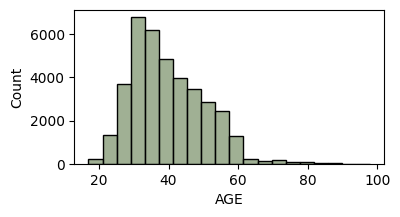

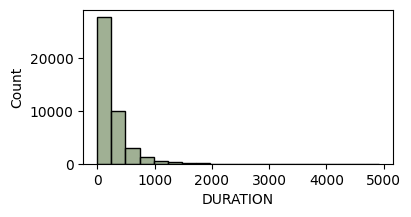

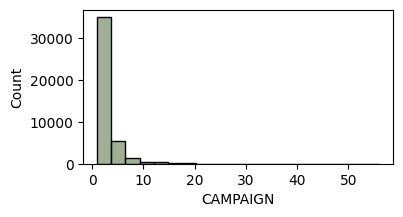

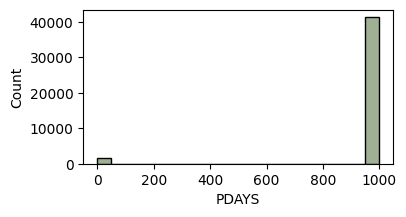

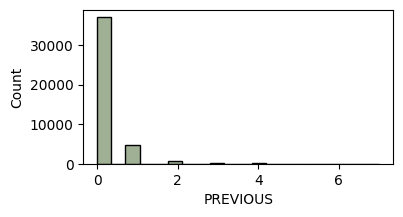

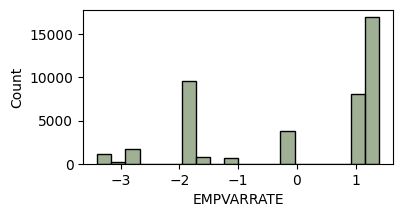

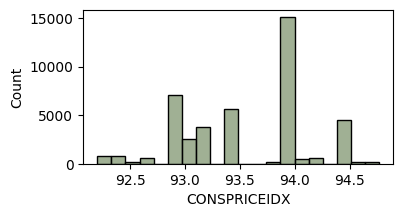

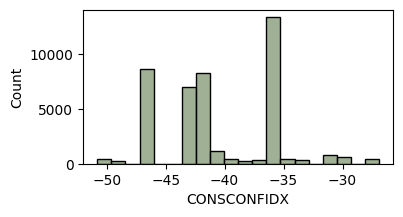

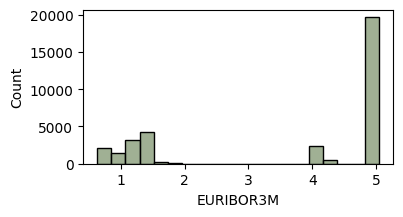

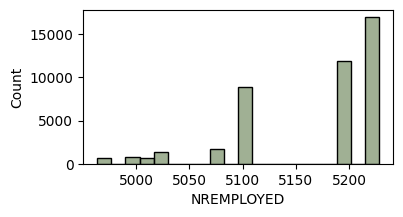

In [26]:
for col in num_bank:
    plt.figure(figsize=(4,2))

    sns.histplot(df_bank[col], bins=20, color='#809671')

    plt.show()

###### Boxplots

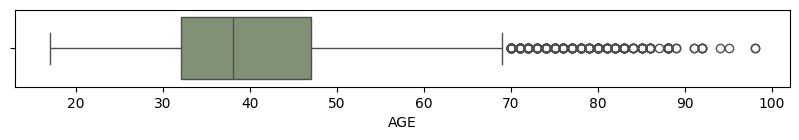

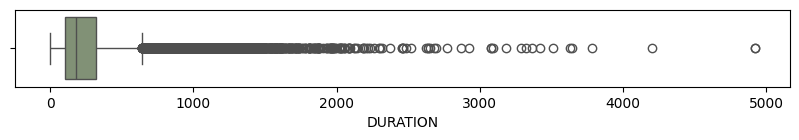

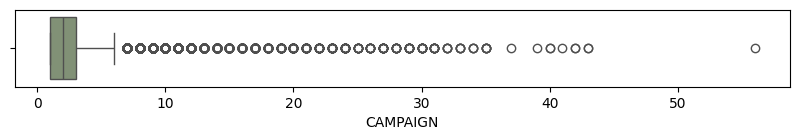

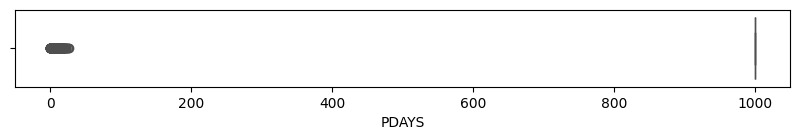

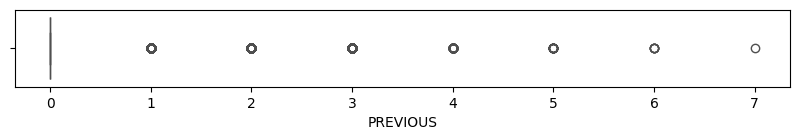

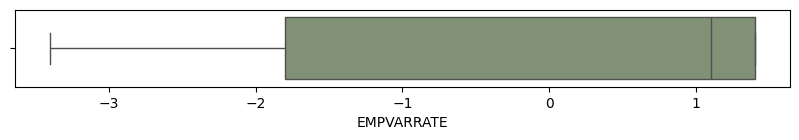

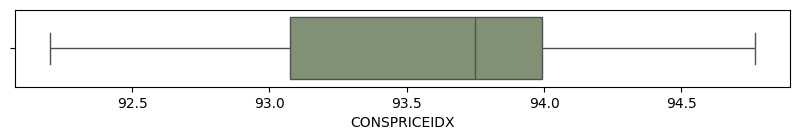

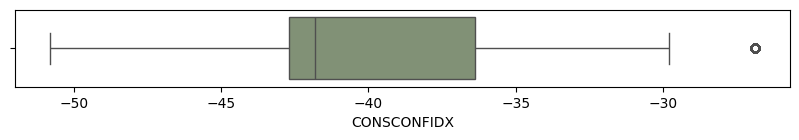

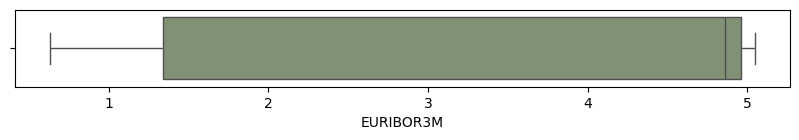

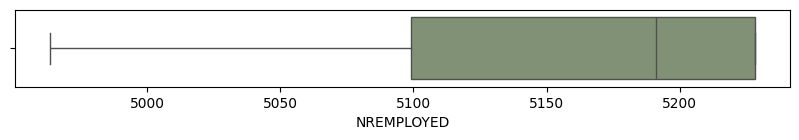

In [27]:
for col in num_bank:
    plt.figure(figsize=(10,1))

    sns.boxplot(x = df_bank[col], color='#809671')

    plt.show()

##### Observaciones 

###### Columnas:
- `AGE`:
    > La edad del cliente.
    
    - Análisis: La mayor parte de clientes se encuentra en un rango de edad entre los 32 y los 47 años, con algunos outliers a partir de los 70 años.
- `DURATION`:
    > La duración en segundos de la última interacción con el cliente.

    -Análisis: La mayor parte de las llamadas oscilan en duracion entre los 2 y los 5 minutos, pero algunas pueden alargarse hasta pasada la hora (outliers)
- `CAMPAIGN`:
    > El número de contactos realizados durante esta campaña para este cliente.

    - Análisis: En la mayor parte de los casos, a cada cliente se le contacta entre 1 y 3 veces. Muy pocas veces pasa de los 10 contactos pero hay un caso que llega a más de 50.
- `PDAYS`:
    > Número de días que han pasado desde la última vez que se contactó con el cliente durante esta campaña.

    - Análisis: Para la gran mayoría de los casos, la última vez que se contactói con los clientes fue hace más de dos años (+999 días que es el maximo reflejado). En muy pocos casos se ha contactado con el mismo cliente a los pocos dias. **COLUMNA MUY POCO INFORMATIVA, se valora eliminar**
- `PREVIOUS`:
    > Número de veces que se ha contactado con el cliente antes de esta campaña.

    - Análisis: En muy pocos casos se había contactado previamente con los clientes con anterioridad, siendo el máximo de veces 7.
- `EMPVARRATE`:
    > La tasa de variación del empleo.

    - Definición: indicador económico que mide el cambio porcentual en el número de personas empleadas durante un período de tiempo específico, comparado con un período anterior.

    - Análisis: Aunque la media y mediana indican una tendencia a una mejora a nivel laboral de la mayoría de usuarios, encontramos una elevada variabilidad (desviación típica) y casos de un empeoramiento más significativo que de mejora -- Más clientes han mejorado, pero el grado de mejora es más modesto, que el nivel de empeoramiento de aquellos que ven empeorada su situación laboral.

- `CONSPRICEIDX`:
    > El índice de precios al consumidor.

    - Definición:  evolución del nivel de precios de una canasta de bienes y servicios representativos del consumo de los hogares

    - Análisis: Los datos sugieren una elevada estabilidad de los precios, donde la variabilidad entre ellos es bastante baja (max: 95, min 92).
    
- `CONSCONFIDX`:
    > El índice de confianza del consumidor.

    - Análisis: Destaca el bajo indice de confianza generalizado (valores siempre negativos)
- `EURIBOR3M`:
    > La tasa de interés de referencia a tres meses.

    - Definición: precio al que los bancos se prestan euros entre sí por un período determinado. Es un "termómetro" del costo del dinero en Europa.

    - Análisis: Elevada variabilidad, encontramos focos en precios altos y bajos, pero no intermedios.

- `NREMPLOYED`:
    > El número de empleados.

    - Análisis:  El gurso de numero de empelados oscila entre los 5000 y los 5200, sin desviarse en exceso de esa cifra en ningún momento.


#### Variables Categóricas

In [28]:
# Creamos un sub-dataframe de columnas categóricas
cat_bank = df_bank.select_dtypes(include=['category', 'object']).columns

In [29]:
df_bank[cat_bank].sample()

,JOB,MARITAL,EDUCATION,DEFAULT,HOUSING,LOAN,CONTACT,POUTCOME,Y,ID
26293,technician,MARRIED,university.degree,No,No,No,cellular,NONEXISTENT,no,43a593b0-1871-4957-af52-0be84f242de8


In [30]:
df_bank[cat_bank].describe().T.round(2)

,count,unique,top,freq
JOB,42655,11,admin.,10873
MARITAL,42915,3,MARRIED,25999
EDUCATION,41193,7,university.degree,12722
DEFAULT,34019,2,No,34016
HOUSING,41974,2,Yes,22498
LOAN,41974,2,No,35442
CONTACT,43000,2,cellular,27396
POUTCOME,43000,3,NONEXISTENT,37103
Y,43000,2,no,38156
ID,43000,43000,993bbbd6-4dbc-4a40-a408-f91f8462bee6,1


Vamos a comprobar los valores únicos de cada columna para hacernos una idea de que tenemos y comprobar si hay algun error o hay que hacer algun ajuste.

La columna ID lógicamente no tiene sentido incluirla en este análisis, ya que es la columna de identificadores únicos, por lo que la eliminamos previamente del análisis (extrayéndola de la lista de columnas categóricas)

In [31]:
cat_bank = cat_bank.drop("ID")

In [ ]:
# Analizamos cuantos valores únicos y cuales tiene cada columna
for col in cat_bank:
    print(f'{col} ({df_bank[col].nunique()})  : {df_bank[col].unique()}\n')

JOB (11)  : ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' nan 'entrepreneur' 'student']

MARITAL (3)  : ['married' 'single' 'divorced' nan]

EDUCATION (7)  : ['basic-4y' 'high-school' 'basic-6y' 'basic-9y' 'professional-course' nan
 'university-degree' 'illiterate']

DEFAULT (2)  : ['no' nan 'yes']

HOUSING (2)  : ['no' 'yes' nan]

LOAN (2)  : ['no' 'yes' nan]

CONTACT (2)  : ['telephone' 'cellular']

POUTCOME (3)  : ['nonexistent' 'failure' 'success']

Y (2)  : ['no' 'yes']



##### Ajustes iniciales

Vamos a hacer un pequeño ajuste de formato para que los valores de todas las columnas estén en minúsculas y que en `EDUCATION` el separador de valores sea un guion en vez de un punto

In [33]:
# Valores de todas las columnas en minúscula, y asegurar que no hay espacios vacíos
for col in cat_bank:
    df_bank[col] = df_bank[col].apply(lambda x : x.lower().strip() if pd.notna(x) else x)

In [34]:
# Ajuste de los valores de la columna `EDUCATION`
df_bank['EDUCATION'] = df_bank['EDUCATION'].apply(lambda x: x.replace('.', '-') if pd.notna(x) else x)

In [35]:
# Y comprobamos que nuestros cambios se han realizado correctamente
df_bank[cat_bank].sample(3)

,JOB,MARITAL,EDUCATION,DEFAULT,HOUSING,LOAN,CONTACT,POUTCOME,Y
788,blue-collar,married,basic-6y,no,no,no,telephone,nonexistent,no
5852,admin.,married,high-school,no,yes,no,telephone,nonexistent,no
2738,admin.,single,university-degree,no,yes,no,telephone,nonexistent,no


Sabemos que tenemos varios valores nulos, para poder tenerlos en cuenta en nuestras visualizaciones vamos a manejarlos con un valor que los señale como "no data"

In [46]:
for col in cat_bank:
    df_bank[col] = df_bank[col].fillna("no data")

##### Visualizaciones

###### Countplot

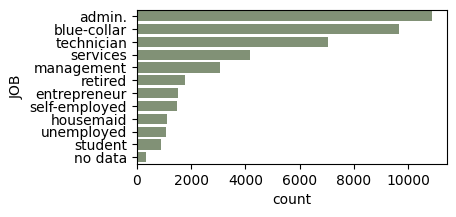

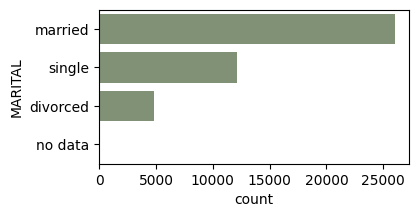

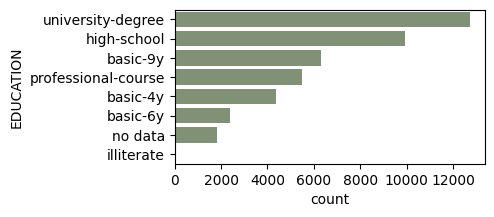

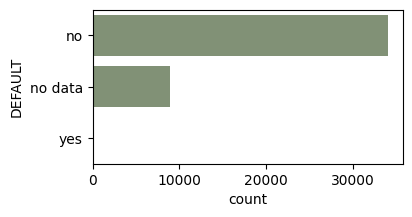

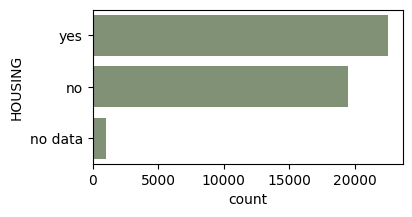

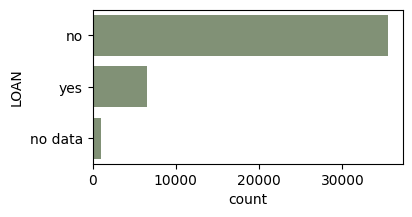

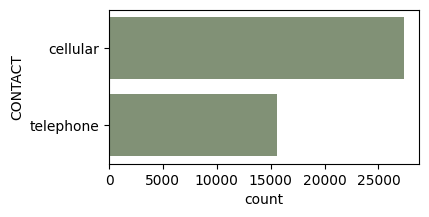

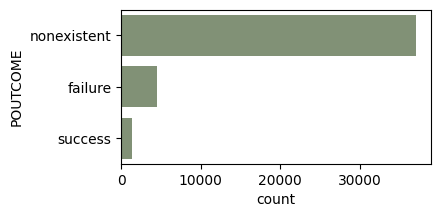

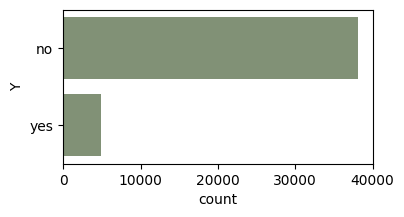

In [52]:
for col in cat_bank:
    # Ordenamos valores según conteo
    order = df_bank[col].value_counts().index

    plt.figure(figsize=(4,2))

    ax = sns.countplot(df_bank[col], order = order, color='#809671')

    # ax.bar_label(ax.containers[0], fontsize=10)

    plt.show()

##### Observaciones

- `job`: La ocupación o profesión del cliente.
    - Análisis: El grueso de ocupación se encuentra en trabajos administrativos, manuales (blue-collar) y técnicos,  siendo estudiantes el mas bajo.
- `marital`: El estado civil del cliente.
    - Análisis: La mayoría casados (mas de la mitad)
- `education`: El nivel educativo del cliente.
    - Análisis: Mayor número en estudios universitarios, pero habría que plantearse unificar la formación básica (por el momento lo dejamos como está por si encontramos algún dato interesante)
- `default`: Indica si el cliente tiene algún historial de incumplimiento de pagos (1: Sí, 0: No).
    - Análisis: No hay casos de incumlimiento de pagos, aunque muchos valores sin información al respecto por lo que no se puede descartar.
- `housing`: Indica si el cliente tiene un préstamo hipotecario (1: Sí, 0: No).
    - Análisis: Número similar de clientes con préstamo hipotecario que sin él
- `loan`: Indica si el cliente tiene algún otro tipo de préstamo (1: Sí, 0: No).
    - Análisis: La mayoría no cuenta con otro tipo de préstamo
- `contact`: El método de contacto utilizado para comunicarse con el cliente.
    - Análisis: Mayor número de contactos por teléfono móvil que por teléfono fijo
- `poutcome`: Resultado de la campaña de marketing anterior.
    - Análisis: En la mayoría de los casos, no había habido contacto anterior con la campaña-
- `y`: Indica si el cliente ha suscrito un producto o servicio (Sí/No).
    - Análisis: La mayor parte de las veces, el cliente no se suscribe al producto. 

#### Variables de Fecha

## Dataset 2:  **customer-details**

Tres hojas diferentes (una por año)

### Contexto columnas:
-	`Income`: Representa el ingreso anual del cliente en términos monetarios.
-	`Kidhome`: Indica el número de niños en el hogar del cliente.
-	`Teenhome`: Indica el número de adolescentes en el hogar del cliente.
-	`Dt_Customer`: Representa la fecha en que el cliente se convirtió en cliente de la empresa.
-	`NumWebVisitsMonth`: Indica la cantidad de visitas mensuales del cliente al sitio web de la empresa.
-	`ID`: Identificador único del cliente.